# Dataset Shift Analysis for CIC IIoT Dataset 2025 vs Edge-IIoTset



In [7]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

if sns is not None:
    sns.set_theme(style="whitegrid")

In [8]:
ROOT = Path.cwd()
DATASETS = {
    "CIC IIoT Dataset 2025": ROOT / "cleaned_merged_full.csv",
    "Edge-IIoTset": ROOT / "cleaned_Edge-IIoTset_aligned.csv",
}

LABEL_PRIORITY = ["label", "label2", "label1", "Attack_type", "Attack", "type", "target", "class"]
DROP_LABEL_COLS = {
    "label", "label1", "label2", "label_full", "Attack_type", "Attack_label",
    "Attack", "Attack_subType", "type", "target", "class"
}

def detect_label_col(df):
    for col in LABEL_PRIORITY:
        if col in df.columns:
            return col
    raise ValueError(f"No label column found. Columns: {list(df.columns[:20])}...")

def stratified_sample(X, y, max_rows=120_000, seed=42):
    if len(X) <= max_rows:
        return X.copy(), y.copy()
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=max_rows, random_state=seed)
    sample_idx, _ = next(splitter.split(X, y))
    return X.iloc[sample_idx].copy(), y.iloc[sample_idx].copy()

def analyze_dataset(name, path):
    df = pd.read_csv(path)
    label_col = detect_label_col(df)
    y = df[label_col].astype(str)

    feature_df = df.drop(columns=[c for c in df.columns if c in DROP_LABEL_COLS], errors="ignore")
    X = feature_df.select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    Xs, ys = stratified_sample(X, y, max_rows=min(120_000, len(X)))

    counts = y.value_counts()
    proportions = y.value_counts(normalize=True)
    minority = counts.min()
    majority = counts.max()
    imbalance_ratio = float(majority / minority)
    normalized_entropy = float(-(proportions * np.log(proportions + 1e-12)).sum() / np.log(len(proportions)))

    corr = Xs.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    upper_values = upper.stack()
    high_corr_80 = int((upper_values >= 0.80).sum())
    high_corr_90 = int((upper_values >= 0.90).sum())
    mean_abs_corr = float(upper_values.mean())
    mean_feature_max_corr = float(upper.max().fillna(0).mean())

    scaled = StandardScaler().fit_transform(Xs)
    pca = PCA(random_state=42).fit(scaled)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    top10_variance = float(cum_var[min(9, len(cum_var) - 1)])
    comps_90 = int(np.searchsorted(cum_var, 0.90) + 1)

    y_codes = pd.Categorical(ys).codes
    mi = mutual_info_classif(Xs, y_codes, discrete_features=False, random_state=42)
    mi_series = pd.Series(mi, index=Xs.columns).sort_values(ascending=False)
    total_mi = float(mi_series.sum())
    top10_mi_share = float(mi_series.head(min(10, len(mi_series))).sum() / total_mi) if total_mi > 0 else np.nan
    top20_mi_share = float(mi_series.head(min(20, len(mi_series))).sum() / total_mi) if total_mi > 0 else np.nan

    summary = {
        "dataset": name,
        "rows": len(df),
        "numeric_features": X.shape[1],
        "classes": y.nunique(),
        "majority_share": proportions.iloc[0],
        "minority_share": proportions.iloc[-1],
        "imbalance_ratio_max_min": imbalance_ratio,
        "normalized_class_entropy": normalized_entropy,
        "corr_pairs_|r|>=0.80": high_corr_80,
        "corr_pairs_|r|>=0.90": high_corr_90,
        "mean_abs_pairwise_corr": mean_abs_corr,
        "mean_feature_max_corr": mean_feature_max_corr,
        "pca_top10_variance_share": top10_variance,
        "components_for_90pct_var": comps_90,
        "top10_MI_share": top10_mi_share,
        "top20_MI_share": top20_mi_share,
    }

    return {
        "raw": df,
        "X": X,
        "y": y,
        "summary": summary,
        "class_counts": counts,
        "class_props": proportions,
        "mi": mi_series,
        "cum_var": cum_var,
    }

results = {name: analyze_dataset(name, path) for name, path in DATASETS.items()}
summary_df = pd.DataFrame([results[name]["summary"] for name in DATASETS]).set_index("dataset")
display(summary_df.round(4))


,rows,numeric_features,classes,majority_share,minority_share,imbalance_ratio_max_min,normalized_class_entropy,corr_pairs_|r|>=0.80,corr_pairs_|r|>=0.90,mean_abs_pairwise_corr,mean_feature_max_corr,pca_top10_variance_share,components_for_90pct_var,top10_MI_share,top20_MI_share
dataset,,,,,,,,,,,,,,,
CIC IIoT Dataset 2025,685671,71,8,0.5844,0.0088,66.6011,0.6520,64,29,0.3893,0.5702,0.9064,10,0.3371,0.5927
Edge-IIoTset,157800,35,15,0.1540,0.0063,24.2767,0.9492,11,10,0.0923,0.4299,0.6839,18,0.8475,0.9813


## 1. Class-Balance Summary



In [9]:
class_summary_rows = []
for name, result in results.items():
    counts = result["class_counts"]
    props = result["class_props"]
    tail_n = min(10, len(counts))
    class_summary_rows.append({
        "Dataset": name,
        "Classes": len(counts),
        "Largest class count": int(counts.iloc[0]),
        "Smallest class count": int(counts.iloc[-1]),
        "Largest class share": float(props.iloc[0]),
        "Smallest class share": float(props.iloc[-1]),
        "Classes below 1%": int((props < 0.01).sum()),
        "Classes below 0.1%": int((props < 0.001).sum()),
        "Share of top-5 classes": float(props.head(min(5, len(props))).sum()),
        "Share of bottom-10 classes": float(props.tail(tail_n).sum()),
    })

class_balance_df = pd.DataFrame(class_summary_rows).set_index("Dataset")
display(class_balance_df.round(4))


,Classes,Largest class count,Smallest class count,Largest class share,Smallest class share,Classes below 1%,Classes below 0.1%,Share of top-5 classes,Share of bottom-10 classes
Dataset,,,,,,,,,
CIC IIoT Dataset 2025,8,400672,6016,0.5844,0.0088,1,0,0.9428,1.0000
Edge-IIoTset,15,24301,1001,0.1540,0.0063,2,0,0.4713,0.5287


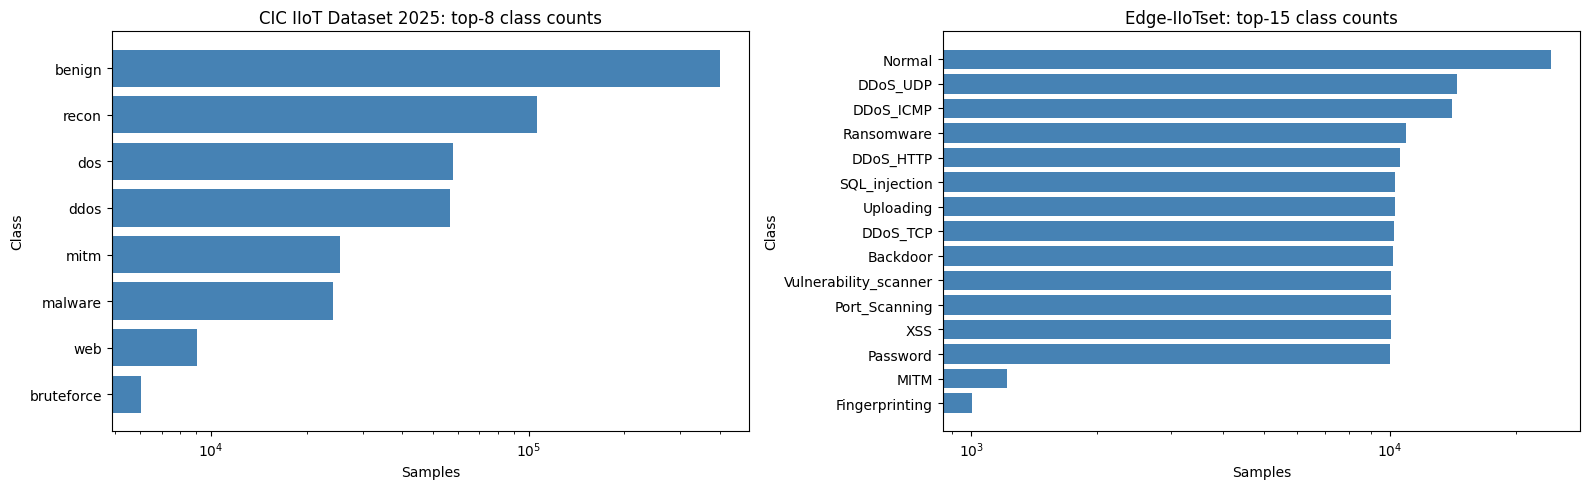

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, result) in zip(axes, results.items()):
    counts = result["class_counts"].sort_values(ascending=False)
    topn = min(25, len(counts))
    values = counts.head(topn).values
    labels = counts.head(topn).index

    if sns is not None:
        sns.barplot(x=values, y=labels, ax=ax, color="steelblue")
    else:
        ax.barh(labels, values, color="steelblue")
        ax.invert_yaxis()

    ax.set_title(f"{name}: top-{topn} class counts")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Class")
    ax.set_xscale("log")

plt.tight_layout()
plt.show()

## 2. Predictive Signal Concentration Across Features



In [12]:
mi_summary = []
for name, result in results.items():
    mi = result["mi"]
    mi_summary.append({
        "Dataset": name,
        "Top-10 MI share": float((mi.head(min(10, len(mi))).sum() / mi.sum()) if mi.sum() > 0 else np.nan),
        "Top-20 MI share": float((mi.head(min(20, len(mi))).sum() / mi.sum()) if mi.sum() > 0 else np.nan),
        "Top feature MI": float(mi.iloc[0]),
        "10th feature MI": float(mi.iloc[min(9, len(mi)-1)]),
        "20th feature MI": float(mi.iloc[min(19, len(mi)-1)]),
    })
display(pd.DataFrame(mi_summary).set_index("Dataset").round(4))


,Top-10 MI share,Top-20 MI share,Top feature MI,10th feature MI,20th feature MI
Dataset,,,,,
CIC IIoT Dataset 2025,0.3371,0.5927,0.7182,0.5308,0.4341
Edge-IIoTset,0.8475,0.9813,1.4111,0.3035,0.0443


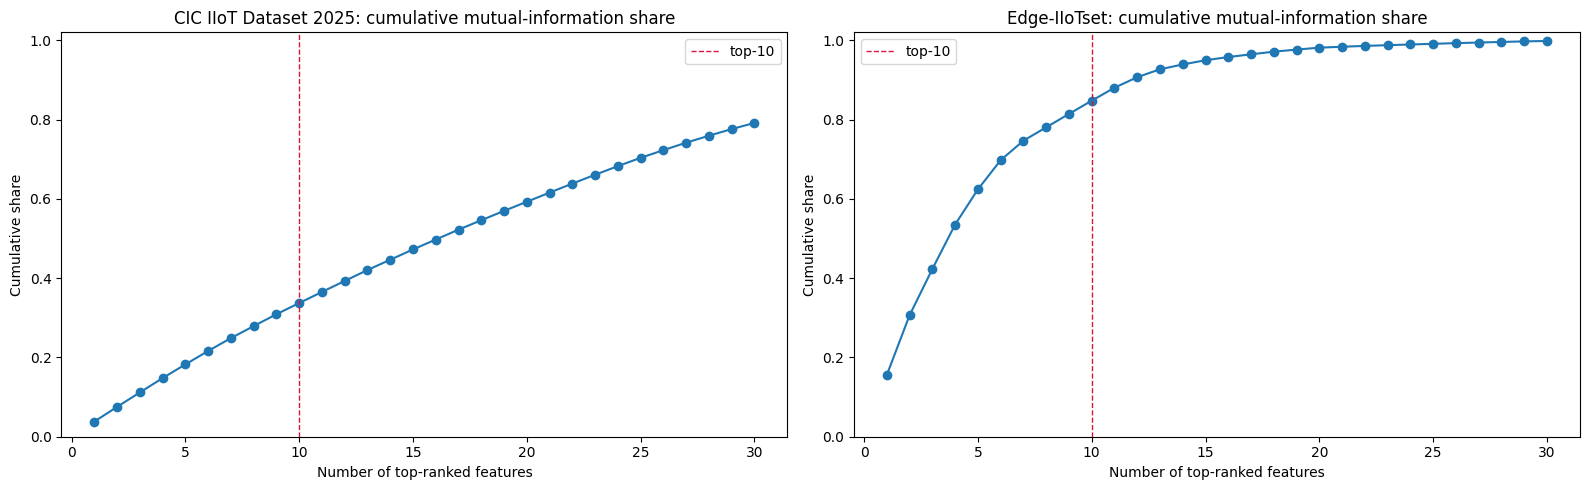

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, result) in zip(axes, results.items()):
    mi = result["mi"]
    cum_share = mi.cumsum() / mi.sum()
    n = min(30, len(mi))
    ax.plot(range(1, n + 1), cum_share.iloc[:n].values, marker="o")
    ax.axvline(10, color="crimson", linestyle="--", linewidth=1, label="top-10")
    ax.set_title(f"{name}: cumulative mutual-information share")
    ax.set_xlabel("Number of top-ranked features")
    ax.set_ylabel("Cumulative share")
    ax.set_ylim(0, 1.02)
    ax.legend()
plt.tight_layout()
plt.show()


## 3. Redundancy and Correlation Structure



In [14]:
corr_summary = summary_df[[
    "numeric_features",
    "corr_pairs_|r|>=0.80",
    "corr_pairs_|r|>=0.90",
    "mean_abs_pairwise_corr",
    "mean_feature_max_corr",
]].copy()
display(corr_summary.round(4))


,numeric_features,corr_pairs_|r|>=0.80,corr_pairs_|r|>=0.90,mean_abs_pairwise_corr,mean_feature_max_corr
dataset,,,,,
CIC IIoT Dataset 2025,71,64,29,0.3893,0.5702
Edge-IIoTset,35,11,10,0.0923,0.4299


## 4. Compression Difficulty via PCA



In [15]:
pca_summary = summary_df[["pca_top10_variance_share", "components_for_90pct_var"]].copy()
display(pca_summary.round(4))


,pca_top10_variance_share,components_for_90pct_var
dataset,,
CIC IIoT Dataset 2025,0.9064,10
Edge-IIoTset,0.6839,18


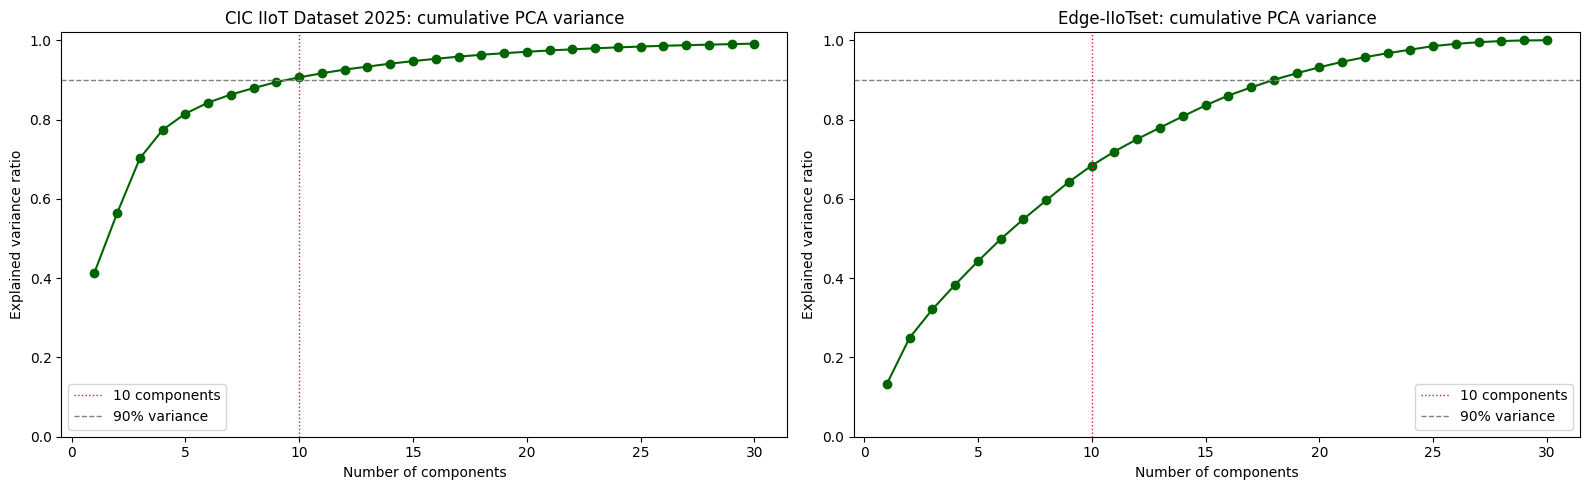

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, result) in zip(axes, results.items()):
    cum_var = result["cum_var"]
    n = min(30, len(cum_var))
    ax.plot(range(1, n + 1), cum_var[:n], marker="o", color="darkgreen")
    ax.axvline(10, color="crimson", linestyle=":", linewidth=1, label="10 components")
    ax.axhline(0.90, color="gray", linestyle="--", linewidth=1, label="90% variance")
    ax.set_title(f"{name}: cumulative PCA variance")
    ax.set_xlabel("Number of components")
    ax.set_ylabel("Explained variance ratio")
    ax.set_ylim(0, 1.02)
    ax.legend()
plt.tight_layout()
plt.show()


## 5. Relative Aggressiveness of a Fixed Top-10 Subset



In [17]:
comparison = summary_df[[
    "rows",
    "numeric_features",
    "classes",
    "imbalance_ratio_max_min",
    "normalized_class_entropy",
    "pca_top10_variance_share",
    "top10_MI_share",
]].copy()
comparison["relative_top10_aggressiveness"] = 10 / summary_df["numeric_features"]
display(comparison.round(4))


,rows,numeric_features,classes,imbalance_ratio_max_min,normalized_class_entropy,pca_top10_variance_share,top10_MI_share,relative_top10_aggressiveness
dataset,,,,,,,,
CIC IIoT Dataset 2025,685671,71,8,66.6011,0.6520,0.9064,0.3371,0.1408
Edge-IIoTset,157800,35,15,24.2767,0.9492,0.6839,0.8475,0.2857
